# Hybrid E-Commerce Recommendation System
### H&M Personalized Fashion Recommendations — Dataset Setup + EDA

**Scope of this notebook:** Step 1 (Kaggle setup & data acquisition) and Step 2 (Exploratory Data Analysis).
No preprocessing, modeling, or deployment is done here — EDA and understanding only.


## Step 1: Environment Setup & Data Acquisition

In [ ]:
!pip install -q kaggle

In [ ]:
import os

os.environ["KAGGLE_API_TOKEN"] = "KGAT_283606f7db27511d5bedbdc1c43c0695"

In [ ]:
# Search competitions by keyword (equivalent of "datasets list -s")
!kaggle competitions list -s "h-and-m"
# List all files inside the competition (confirms exact filenames + sizes)
!kaggle competitions files -c h-and-m-personalized-fashion-recommendations

ref                                                                               deadline             category      reward  teamCount  userHasEntered  
--------------------------------------------------------------------------------  -------------------  --------  ----------  ---------  --------------  
https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations  2022-05-09 23:59:00  Featured  50,000 Usd       2952            True  
Next Page Token = CfDJ8EgiEKLz2SFKpKvT-xxAYKLoKBhsCS6myj0ZRAEnLnFKcgqn6mEK76n3mf4LLc72tBK6WDZnd6yklaiZGfnSajE7fGCqIDszFEZk1Ww6zPrdAp4JsPkPRAhswveU3hTK203Z3uoqSTZTCWjPH0GV6skXsw
name                             size  creationDate                
-------------------------  ----------  --------------------------  
articles.csv                 36127865  2022-01-17 19:56:38.411000  
customers.csv               207135859  2022-01-17 19:56:42.498000  
images/010/0108775015.jpg      154607  2022-01-17 20:11:11.277000  
images/010/0108775044.jp

In [ ]:
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f articles.csv
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f customers.csv
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f transactions_train.csv

!ls -lh *.zip *.csv 2>/dev/null

100% 4.26M/4.26M [00:01<00:00, 3.15MB/s]

100% 97.9M/97.9M [00:05<00:00, 18.2MB/s]

100% 584M/584M [00:28<00:00, 21.4MB/s]

-rw-r--r-- 1 root root 4.3M Jan 17  2022  articles.csv.zip
-rw-r--r-- 1 root root  98M Jan 17  2022  customers.csv.zip
-rw-r--r-- 1 root root 585M Jan 17  2022  transactions_train.csv.zip


### 1.5 Extract downloaded files

In [ ]:
import zipfile
import os

files_to_extract = ["articles.csv.zip", "customers.csv.zip", "transactions_train.csv.zip"]

for f in files_to_extract:
    if os.path.exists(f):
        with zipfile.ZipFile(f, 'r') as zip_ref:
            zip_ref.extractall(".")
        print(f"Extracted: {f}")
    else:
        print(f"Not a zip (likely already extracted): {f.replace('.zip', '')}")

!ls -lh *.csv

Extracted: articles.csv.zip
Extracted: customers.csv.zip
Extracted: transactions_train.csv.zip
-rw-r--r-- 1 root root  35M Jul  7 13:04 articles.csv
-rw-r--r-- 1 root root 198M Jul  7 13:04 customers.csv
-rw-r--r-- 1 root root 3.3G Jul  7 13:05 transactions_train.csv


In [ ]:
import os

for fname in ["articles.csv", "customers.csv", "transactions_train.csv"]:
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / (1024 * 1024)
        print(f"{fname}: {size_mb:.1f} MB — OK")
    else:
        print(f"{fname}: MISSING — check Cell 7/8 output for errors")

articles.csv: 34.5 MB — OK
customers.csv: 197.5 MB — OK
transactions_train.csv: 3326.4 MB — OK


### 1.7 Load into pandas (memory-efficient dtypes for the large transactions file)

In [ ]:
import pandas as pd

# Product metadata — small enough to load fully, no dtype tuning needed
articles = pd.read_csv("articles.csv")

# Customer metadata — small enough to load fully
customers = pd.read_csv("customers.csv")

# Transactions (~31M rows) — specify dtypes upfront to avoid pandas defaulting
# numeric columns to int64/float64, which roughly doubles memory usage
transactions = pd.read_csv(
    "transactions_train.csv",
    dtype={
        "article_id": "int32",
        "customer_id": "str",
        "price": "float32",
        "sales_channel_id": "int8"
    },
    parse_dates=["t_dat"]
)

print("Articles:", articles.shape)
print("Customers:", customers.shape)
print("Transactions:", transactions.shape)

Articles: (105542, 25)
Customers: (1371980, 7)
Transactions: (31788324, 5)


### 1.8 Initial inspection

In [ ]:
def inspect(df, name):
    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Shape:", df.shape)
    print("\nColumns and dtypes:")
    print(df.dtypes)
    print("\nMissing values (top 10):")
    print(df.isnull().sum().sort_values(ascending=False).head(10))
    print("\nDuplicate rows:", df.duplicated().sum())
    print("\nFirst 5 rows:")
    display(df.head())
    print("\nBasic statistics:")
    display(df.describe(include="all").transpose().head(10))

inspect(articles, "Articles (Product Metadata)")
inspect(customers, "Customers (User Metadata)")
inspect(transactions, "Transactions (User-Item Interactions)")


Articles (Product Metadata)
Shape: (105542, 25)

Columns and dtypes:
article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_value_id        int64
perceived_colour_value_name     object
perceived_colour_master_id       int64
perceived_colour_master_name    object
department_no                    int64
department_name                 object
index_code                      object
index_name                      object
index_group_no                   int64
index_group_name                object
section_no                       int64
section_name                    object
garment_group_no                 int64
garment_group_name              o

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
article_id,105542.0,NaN,NaN,NaN,698424569.096919,128462381.336161,108775015.0,616992501.0,702213001.5,796703001.75,959461001.0
product_code,105542.0,NaN,NaN,NaN,698424.563378,128462.384432,108775.0,616992.5,702213.0,796703.0,959461.0
prod_name,105542,45875,Dragonfly dress,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_type_no,105542.0,NaN,NaN,NaN,234.861875,75.049308,-1.0,252.0,259.0,272.0,762.0
product_type_name,105542,131,Trousers,11169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_group_name,105542,19,Garment Upper body,42741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
graphical_appearance_no,105542.0,NaN,NaN,NaN,1009515.075723,22413.585778,-1.0,1010008.0,1010016.0,1010016.0,1010029.0
graphical_appearance_name,105542,30,Solid,49747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
colour_group_code,105542.0,NaN,NaN,NaN,32.233822,28.086154,-1.0,9.0,14.0,52.0,93.0
colour_group_name,105542,50,Black,22670,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Customers (User Metadata)
Shape: (1371980, 7)

Columns and dtypes:
customer_id                object
FN                        float64
Active                    float64
club_member_status         object
fashion_news_frequency     object
age                       float64
postal_code                object
dtype: object

Missing values (top 10):
Active                    907576
FN                        895050
fashion_news_frequency     16011
age                        15861
club_member_status          6062
customer_id                    0
postal_code                    0
dtype: int64

Duplicate rows: 0

First 5 rows:


...

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1371980,1371980,ffffd9ac14e89946416d80e791d064701994755c3ab686...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN,476930.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Active,464404.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
club_member_status,1365918,3,ACTIVE,1272491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fashion_news_frequency,1355969,3,NONE,877711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1356119.0,NaN,NaN,NaN,36.386965,14.313628,16.0,24.0,32.0,49.0,99.0
postal_code,1371980,352899,2c29ae653a9282cce4151bd87643c907644e09541abc28...,120303,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Transactions (User-Item Interactions)
Shape: (31788324, 5)

Columns and dtypes:
t_dat               datetime64[ns]
customer_id                 object
article_id                   int32
price                      float32
sales_channel_id              int8
dtype: object

Missing values (top 10):
t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

Duplicate rows: 2974905

First 5 rows:


,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2



Basic statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
t_dat,31788324,NaN,NaN,NaN,2019-09-15 17:27:46.894452992,2018-09-20 00:00:00,2019-03-28 00:00:00,2019-08-25 00:00:00,2020-03-29 00:00:00,2020-09-22 00:00:00,NaN
customer_id,31788324,1362281,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
article_id,31788324.0,NaN,NaN,NaN,696227219.133793,108775015.0,632803008.0,714582003.0,786524001.0,956217002.0,133448003.487369
price,31788324.0,NaN,NaN,NaN,0.027829,0.000017,0.015814,0.025407,0.033881,0.591525,0.018332
sales_channel_id,31788324.0,NaN,NaN,NaN,1.704028,1.0,1.0,2.0,2.0,2.0,0.456479


---
## Step 2: Exploratory Data Analysis (EDA) & Data Understanding

**Important note on ratings:** H&M has no explicit star-rating column — it is **implicit feedback**
(purchase transactions only). Wherever "rating analysis" is required below, we use
**purchase frequency per (customer, article) pair** as an implicit preference-strength proxy,
and we are explicit that this is a proxy, not a true rating.


### Part A: Dataset Overview

**A.1 Dimensions, columns, dtypes**

In [ ]:
for name, df in [("articles", articles), ("customers", customers), ("transactions", transactions)]:
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"{name}: {mem_mb:.1f} MB in memory, {df.shape[0]:,} rows")

articles: 106.3 MB in memory, 105,542 rows
customers: 470.6 MB in memory, 1,371,980 rows
transactions: 3941.0 MB in memory, 31,788,324 rows


In [ ]:
for name, df in [("Articles", articles), ("Customers", customers), ("Transactions", transactions)]:
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print("Shape (rows, columns):", df.shape)
    print("\nColumn names:")
    print(list(df.columns))
    print("\nData types:")
    print(df.dtypes)


Articles
Shape (rows, columns): (105542, 25)

Column names:
['article_id', 'product_code', 'prod_name', 'product_type_no', 'product_type_name', 'product_group_name', 'graphical_appearance_no', 'graphical_appearance_name', 'colour_group_code', 'colour_group_name', 'perceived_colour_value_id', 'perceived_colour_value_name', 'perceived_colour_master_id', 'perceived_colour_master_name', 'department_no', 'department_name', 'index_code', 'index_name', 'index_group_no', 'index_group_name', 'section_no', 'section_name', 'garment_group_no', 'garment_group_name', 'detail_desc']

Data types:
article_id                       int64
product_code                     int64
prod_name                       object
product_type_no                  int64
product_type_name               object
product_group_name              object
graphical_appearance_no          int64
graphical_appearance_name       object
colour_group_code                int64
colour_group_name               object
perceived_colour_valu

**A.2 Summary statistics**

In [ ]:
print("ARTICLES — summary statistics")
display(articles.describe(include="all").transpose())

print("\nCUSTOMERS — summary statistics")
display(customers.describe(include="all").transpose())

print("\nTRANSACTIONS — summary statistics")
display(transactions.describe(include="all").transpose())

ARTICLES — summary statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
article_id,105542.0,NaN,NaN,NaN,698424569.096919,128462381.336161,108775015.0,616992501.0,702213001.5,796703001.75,959461001.0
product_code,105542.0,NaN,NaN,NaN,698424.563378,128462.384432,108775.0,616992.5,702213.0,796703.0,959461.0
prod_name,105542,45875,Dragonfly dress,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_type_no,105542.0,NaN,NaN,NaN,234.861875,75.049308,-1.0,252.0,259.0,272.0,762.0
product_type_name,105542,131,Trousers,11169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_group_name,105542,19,Garment Upper body,42741,NaN,NaN,NaN,NaN,NaN,NaN,NaN
graphical_appearance_no,105542.0,NaN,NaN,NaN,1009515.075723,22413.585778,-1.0,1010008.0,1010016.0,1010016.0,1010029.0
graphical_appearance_name,105542,30,Solid,49747,NaN,NaN,NaN,NaN,NaN,NaN,NaN
colour_group_code,105542.0,NaN,NaN,NaN,32.233822,28.086154,-1.0,9.0,14.0,52.0,93.0
colour_group_name,105542,50,Black,22670,NaN,NaN,NaN,NaN,NaN,NaN,NaN



CUSTOMERS — summary statistics


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,1371980,1371980,ffffd9ac14e89946416d80e791d064701994755c3ab686...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN,476930.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Active,464404.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
club_member_status,1365918,3,ACTIVE,1272491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fashion_news_frequency,1355969,3,NONE,877711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1356119.0,NaN,NaN,NaN,36.386965,14.313628,16.0,24.0,32.0,49.0,99.0
postal_code,1371980,352899,2c29ae653a9282cce4151bd87643c907644e09541abc28...,120303,NaN,NaN,NaN,NaN,NaN,NaN,NaN



TRANSACTIONS — summary statistics


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
t_dat,31788324,NaN,NaN,NaN,2019-09-15 17:27:46.894452992,2018-09-20 00:00:00,2019-03-28 00:00:00,2019-08-25 00:00:00,2020-03-29 00:00:00,2020-09-22 00:00:00,NaN
customer_id,31788324,1362281,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895,NaN,NaN,NaN,NaN,NaN,NaN,NaN
article_id,31788324.0,NaN,NaN,NaN,696227219.133793,108775015.0,632803008.0,714582003.0,786524001.0,956217002.0,133448003.487369
price,31788324.0,NaN,NaN,NaN,0.027829,0.000017,0.015814,0.025407,0.033881,0.591525,0.018332
sales_channel_id,31788324.0,NaN,NaN,NaN,1.704028,1.0,1.0,2.0,2.0,2.0,0.456479


**A.3 Missing values analysis**

In [ ]:
def missing_report(df, name):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct.round(2)})
    report = report[report["missing_count"] > 0].sort_values("missing_count", ascending=False)
    print(f"\n{name} — columns with missing values:")
    if report.empty:
        print("None found.")
    else:
        display(report)

missing_report(articles, "Articles")
missing_report(customers, "Customers")
missing_report(transactions, "Transactions")


Articles — columns with missing values:


,missing_count,missing_pct
detail_desc,416,0.39



Customers — columns with missing values:


,missing_count,missing_pct
Active,907576,66.15
FN,895050,65.24
fashion_news_frequency,16011,1.17
age,15861,1.16
club_member_status,6062,0.44



Transactions — columns with missing values:
None found.


**A.4 Duplicate records analysis**

In [ ]:
print("Duplicate rows in Articles:", articles.duplicated().sum())
print("Duplicate rows in Customers:", customers.duplicated().sum())
print("Duplicate rows in Transactions:", transactions.duplicated().sum())

# A transaction can legitimately repeat (same customer buying the same item on
# different days), so we also check duplicate (customer, article, date) combos
exact_dupe_transactions = transactions.duplicated(subset=["customer_id", "article_id", "t_dat"]).sum()
print("Exact duplicate (customer + article + date) transaction rows:", exact_dupe_transactions)


Duplicate rows in Articles: 0
Duplicate rows in Customers: 0
Duplicate rows in Transactions: 2974905
Exact duplicate (customer + article + date) transaction rows: 3212929


**A.5 Memory usage**

In [ ]:
for name, df in [("Articles", articles), ("Customers", customers), ("Transactions", transactions)]:
    mem_mb = df.memory_usage(deep=True).sum() / (1024 ** 2)
    print(f"{name}: {mem_mb:,.1f} MB")


Articles: 106.3 MB
Customers: 470.6 MB
Transactions: 3,941.0 MB


**A.6-A.10 Unique users, unique products, total interactions**

In [ ]:
n_users = transactions["customer_id"].nunique()
n_products = transactions["article_id"].nunique()
n_interactions = len(transactions)

print(f"Unique users (who made at least 1 purchase): {n_users:,}")
print(f"Unique products (that were purchased at least once): {n_products:,}")
print(f"Total interactions (transaction rows): {n_interactions:,}")
print(f"\nTotal customers in customers.csv: {customers.shape[0]:,}")
print(f"Total products in articles.csv: {articles.shape[0]:,}")


Unique users (who made at least 1 purchase): 1,362,281
Unique products (that were purchased at least once): 104,547
Total interactions (transaction rows): 31,788,324

Total customers in customers.csv: 1,371,980
Total products in articles.csv: 105,542


> **Business insight:** `n_users`/`n_products` from transactions are smaller than the totals
> in `customers.csv`/`articles.csv`. This gap tells us some customers never purchased anything
> (pure cold-start users) and some articles were never sold in this window (cold-start items) —
> both need to be handled by our hybrid system later.


### Part B: User Analysis

**B.1 Interactions per user, most active users, avg/median**

In [ ]:
user_activity = transactions.groupby("customer_id").size().reset_index(name="num_interactions")

print("Most active users (top 10):")
display(user_activity.sort_values("num_interactions", ascending=False).head(10))

print(f"\nAverage interactions per user: {user_activity['num_interactions'].mean():.2f}")
print(f"Median interactions per user: {user_activity['num_interactions'].median():.2f}")
print(f"Min interactions per user: {user_activity['num_interactions'].min()}")
print(f"Max interactions per user: {user_activity['num_interactions'].max()}")
print(f"Std deviation: {user_activity['num_interactions'].std():.2f}")


Most active users (top 10):


,customer_id,num_interactions
1011710,be1981ab818cf4ef6765b2ecaea7a2cbf14ccd6e8a7ee9...,1895
962395,b4db5e5259234574edfff958e170fe3a5e13b6f146752c...,1441
391840,49beaacac0c7801c2ce2d189efe525fe80b5d37e46ed05...,1364
885174,a65f77281a528bf5c1e9f270141d601d116e1df33bf9df...,1361
1090960,cd04ec2726dd58a8c753e0d6423e57716fd9ebcf2f14ed...,1237
456062,55d15396193dfd45836af3a6269a079efea339e875eff4...,1208
1028179,c140410d72a41ee5e2e3ba3d7f5a860f337f1b5e41c27c...,1170
755132,8df45859ccd71ef1e48e2ee9d1c65d5728c31c46ae957d...,1169
20162,03d0011487606c37c1b1ed147fc72f285a50c05f00b971...,1157
578832,6cc121e5cc202d2bf344ffe795002bdbf87178054bcda2...,1143



Average interactions per user: 23.33
Median interactions per user: 9.00
Min interactions per user: 1
Max interactions per user: 1895
Std deviation: 39.24


**B.2 Histogram of user activity**

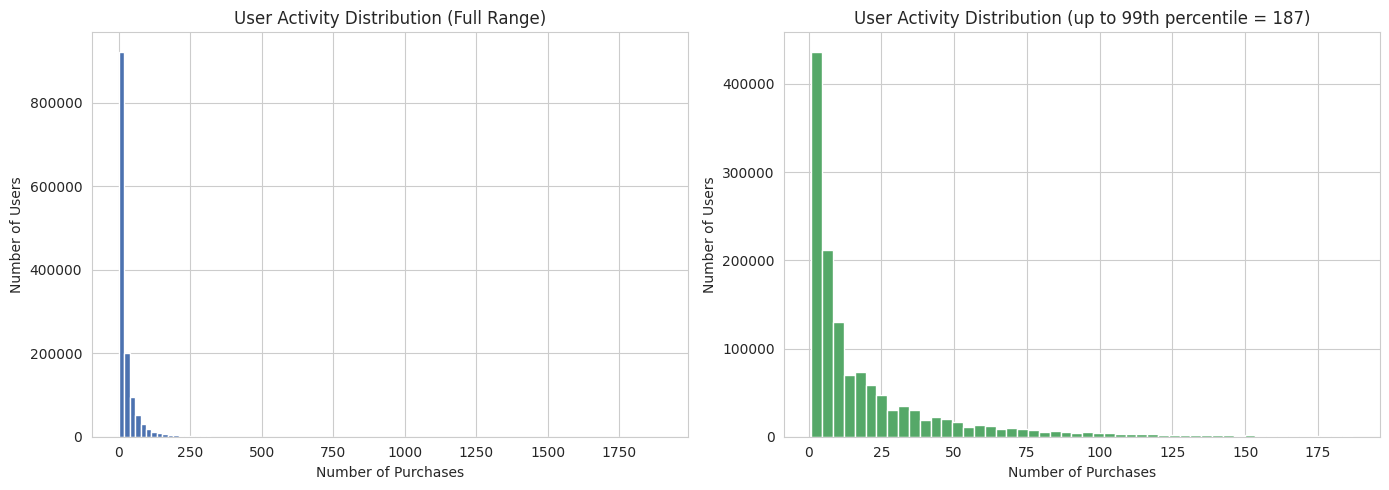

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full distribution (will be extremely right-skewed)
axes[0].hist(user_activity["num_interactions"], bins=100, color="#4C72B0")
axes[0].set_title("User Activity Distribution (Full Range)")
axes[0].set_xlabel("Number of Purchases")
axes[0].set_ylabel("Number of Users")

# Zoomed-in view (99th percentile) since most users buy very little
p99 = user_activity["num_interactions"].quantile(0.99)
axes[1].hist(user_activity[user_activity["num_interactions"] <= p99]["num_interactions"],
             bins=50, color="#55A868")
axes[1].set_title(f"User Activity Distribution (up to 99th percentile = {p99:.0f})")
axes[1].set_xlabel("Number of Purchases")
axes[1].set_ylabel("Number of Users")

plt.tight_layout()
plt.show()


**B.3 Low-activity user check (cold-start signal)**

In [ ]:
for threshold in [1, 2, 5, 10]:
    pct = (user_activity["num_interactions"] <= threshold).mean() * 100
    print(f"Users with <= {threshold} purchase(s): {pct:.2f}%")


Users with <= 1 purchase(s): 9.65%
Users with <= 2 purchase(s): 19.01%
Users with <= 5 purchase(s): 36.80%
Users with <= 10 purchase(s): 52.89%


> **Business insight:** Real e-commerce user activity almost always follows a power-law /
> long-tail pattern — a small fraction of users buy a lot, and the vast majority buy just once
> or twice. This directly affects collaborative filtering: low-activity users give the model
> almost no signal (the cold-start problem), so content-based filtering is essential for them.


### Part C: Product Analysis

**C.1 Most purchased products**

In [ ]:
product_popularity = transactions.groupby("article_id").size().reset_index(name="num_purchases")
product_popularity = product_popularity.merge(
    articles[["article_id", "prod_name", "product_type_name", "product_group_name"]],
    on="article_id", how="left"
)

print("Top 15 best-selling products:")
display(product_popularity.sort_values("num_purchases", ascending=False).head(15))


Top 15 best-selling products:


,article_id,num_purchases,prod_name,product_type_name,product_group_name
53832,706016001,50287,Jade HW Skinny Denim TRS,Trousers,Garment Lower body
53833,706016002,35043,Jade HW Skinny Denim TRS,Trousers,Garment Lower body
1711,372860001,31718,7p Basic Shaftless,Socks,Socks & Tights
24808,610776002,30199,Tilly (1),T-shirt,Garment Upper body
70124,759871002,26329,Tilda tank,Vest top,Garment Upper body
3706,464297007,25025,Greta Thong Mynta Low 3p,Underwear bottom,Underwear
1712,372860002,24458,7p Basic Shaftless,Socks,Socks & Tights
24807,610776001,22451,Tilly (1),T-shirt,Garment Upper body
2233,399223001,22236,Curvy Jeggings HW Ankle,Trousers,Garment Lower body
53834,706016003,21241,Jade HW Skinny Denim TRS,Trousers,Garment Lower body


**C.2 Product popularity distribution + category distribution**

/tmp/ipykernel_699/2777429346.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[1], palette="viridis")


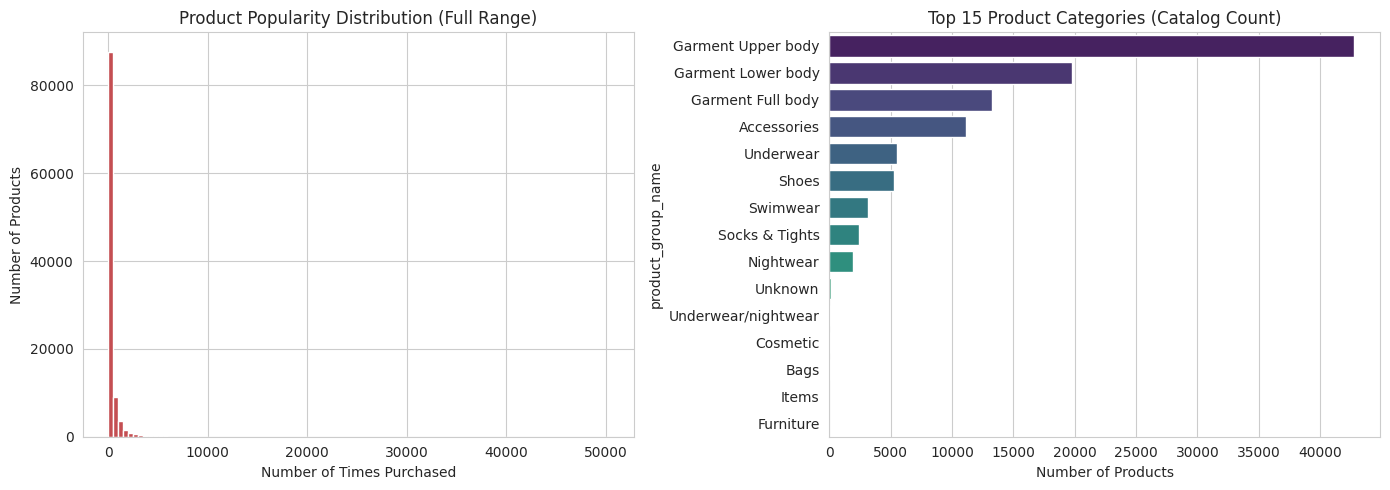

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(product_popularity["num_purchases"], bins=100, color="#C44E52")
axes[0].set_title("Product Popularity Distribution (Full Range)")
axes[0].set_xlabel("Number of Times Purchased")
axes[0].set_ylabel("Number of Products")

top_categories = articles["product_group_name"].value_counts().head(15)
sns.barplot(x=top_categories.values, y=top_categories.index, ax=axes[1], palette="viridis")
axes[1].set_title("Top 15 Product Categories (Catalog Count)")
axes[1].set_xlabel("Number of Products")

plt.tight_layout()
plt.show()


**C.3 Long-tail distribution (rank vs. popularity, log-log scale)**

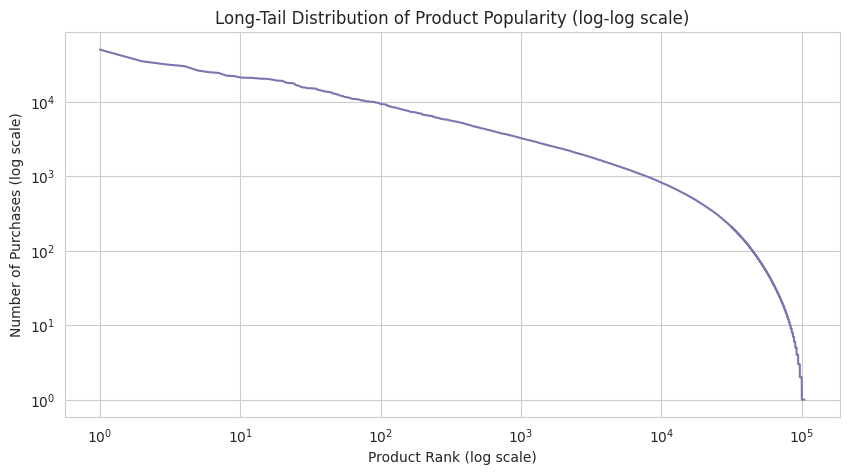

Top 20% of products account for 79.1% of all purchases


In [ ]:
sorted_popularity = product_popularity.sort_values("num_purchases", ascending=False).reset_index(drop=True)
sorted_popularity["rank"] = sorted_popularity.index + 1

plt.figure(figsize=(10, 5))
plt.plot(sorted_popularity["rank"], sorted_popularity["num_purchases"], color="#8172B2")
plt.yscale("log")
plt.xscale("log")
plt.title("Long-Tail Distribution of Product Popularity (log-log scale)")
plt.xlabel("Product Rank (log scale)")
plt.ylabel("Number of Purchases (log scale)")
plt.show()

# What % of total purchases come from top 20% of products?
top20_cutoff = int(len(sorted_popularity) * 0.2)
top20_purchases = sorted_popularity.iloc[:top20_cutoff]["num_purchases"].sum()
total_purchases = sorted_popularity["num_purchases"].sum()
print(f"Top 20% of products account for {top20_purchases / total_purchases * 100:.1f}% of all purchases")


> **Business insight:** The near-straight line on the log-log plot is the signature of a
> long-tail catalog — a small set of "hero" products drive most sales, while thousands of
> niche products get purchased rarely. A pure popularity-based recommender would just repeat
> the same bestsellers to everyone; item-item CF will be strong for popular items but weak for
> tail items — another place content-based filtering fills the gap.


### Part D: Rating Analysis (Adapted for Implicit Feedback)

**D.1 Implicit \"rating\" proxy (purchase count per user-item pair)**

In [ ]:
from scipy.stats import skew

implicit_rating = transactions.groupby(["customer_id", "article_id"]).size().reset_index(name="purchase_count")

print("Distribution of purchase_count (implicit rating proxy):")
print(implicit_rating["purchase_count"].describe())

mean_val = implicit_rating["purchase_count"].mean()
median_val = implicit_rating["purchase_count"].median()
std_val = implicit_rating["purchase_count"].std()
skew_val = skew(implicit_rating["purchase_count"])

print(f"\nMean: {mean_val:.3f}")
print(f"Median: {median_val:.3f}")
print(f"Std Dev: {std_val:.3f}")
print(f"Skewness: {skew_val:.3f}")


Distribution of purchase_count (implicit rating proxy):
count    2.730644e+07
mean     1.164133e+00
std      5.721803e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      5.700000e+02
Name: purchase_count, dtype: float64

Mean: 1.164
Median: 1.000
Std Dev: 0.572
Skewness: 56.813


**D.2 Visualize repeat-purchase distribution**

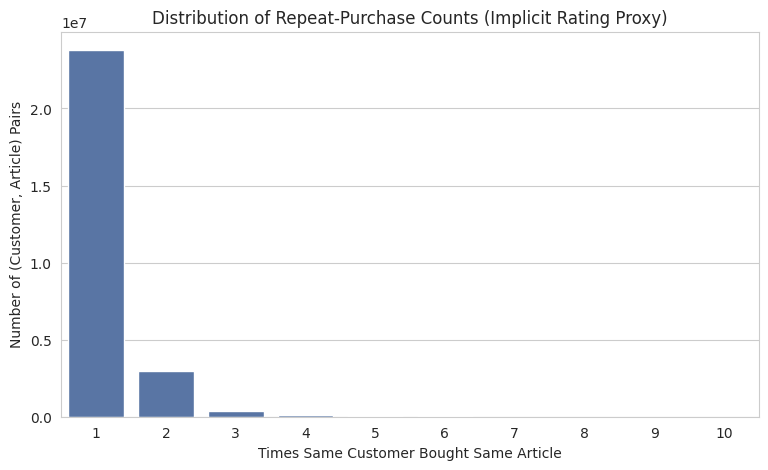

In [ ]:
plt.figure(figsize=(9, 5))
value_counts = implicit_rating["purchase_count"].value_counts().sort_index().head(10)
sns.barplot(x=value_counts.index, y=value_counts.values, color="#4C72B0")
plt.title("Distribution of Repeat-Purchase Counts (Implicit Rating Proxy)")
plt.xlabel("Times Same Customer Bought Same Article")
plt.ylabel("Number of (Customer, Article) Pairs")
plt.show()


> **Business insight:** A skewness value far above 0 confirms most (customer, product) pairs
> are bought exactly once — repeat purchases of the *identical* item are rare for fashion. This
> means "rating imbalance" here isn't about star-rating bias (there are no stars), it's about a
> **binary-dominant implicit signal**: treating interactions as binary (bought / not bought) is
> likely more appropriate than treating purchase count as a strength gradient.


### Part E: User-Item Interaction Matrix

**Important:** With ~1.37M users × ~105K products, a *dense* matrix would need roughly
144 billion cells — that would crash Colab instantly. We compute sparsity analytically and only
materialize a **sparse matrix** (which only stores non-zero entries).


**E.1 Sparsity calculation (no dense matrix built)**

In [ ]:
num_users = transactions["customer_id"].nunique()
num_items = transactions["article_id"].nunique()
num_interactions = transactions.drop_duplicates(subset=["customer_id", "article_id"]).shape[0]

total_possible_cells = num_users * num_items
sparsity = 1 - (num_interactions / total_possible_cells)
density = 100 - (sparsity * 100)

print(f"Matrix dimensions: {num_users:,} users x {num_items:,} products")
print(f"Total possible cells: {total_possible_cells:,}")
print(f"Actual filled cells (unique user-item pairs): {num_interactions:,}")
print(f"Sparsity: {sparsity*100:.6f}%")
print(f"Density: {density:.6f}%")


Matrix dimensions: 1,362,281 users x 104,547 products
Total possible cells: 142,422,391,707
Actual filled cells (unique user-item pairs): 27,306,439
Sparsity: 99.980827%
Density: 0.019173%


**E.2 Build the matrix in SPARSE format (memory-safe)**

In [ ]:
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder

# Encode string IDs into integer indices required for a sparse matrix
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

interaction_pairs = transactions.drop_duplicates(subset=["customer_id", "article_id"]).copy()
interaction_pairs["user_idx"] = user_encoder.fit_transform(interaction_pairs["customer_id"])
interaction_pairs["item_idx"] = item_encoder.fit_transform(interaction_pairs["article_id"])

sparse_matrix = csr_matrix(
    (
        [1] * len(interaction_pairs),          # value = 1 (implicit: purchased)
        (interaction_pairs["user_idx"], interaction_pairs["item_idx"])
    ),
    shape=(num_users, num_items)
)

print("Sparse matrix shape:", sparse_matrix.shape)
print("Non-zero entries stored:", sparse_matrix.nnz)
print(f"Memory used by sparse matrix: {sparse_matrix.data.nbytes / (1024**2):.2f} MB")
print(f"(A dense version of this matrix would need approximately "
      f"{(total_possible_cells * 1) / (1024**3):.1f} GB — completely infeasible)")


Sparse matrix shape: (1362281, 104547)
Non-zero entries stored: 27306439
Memory used by sparse matrix: 208.33 MB
(A dense version of this matrix would need approximately 132.6 GB — completely infeasible)


**E.3 Sample heatmap: top 40 users x top 40 products**

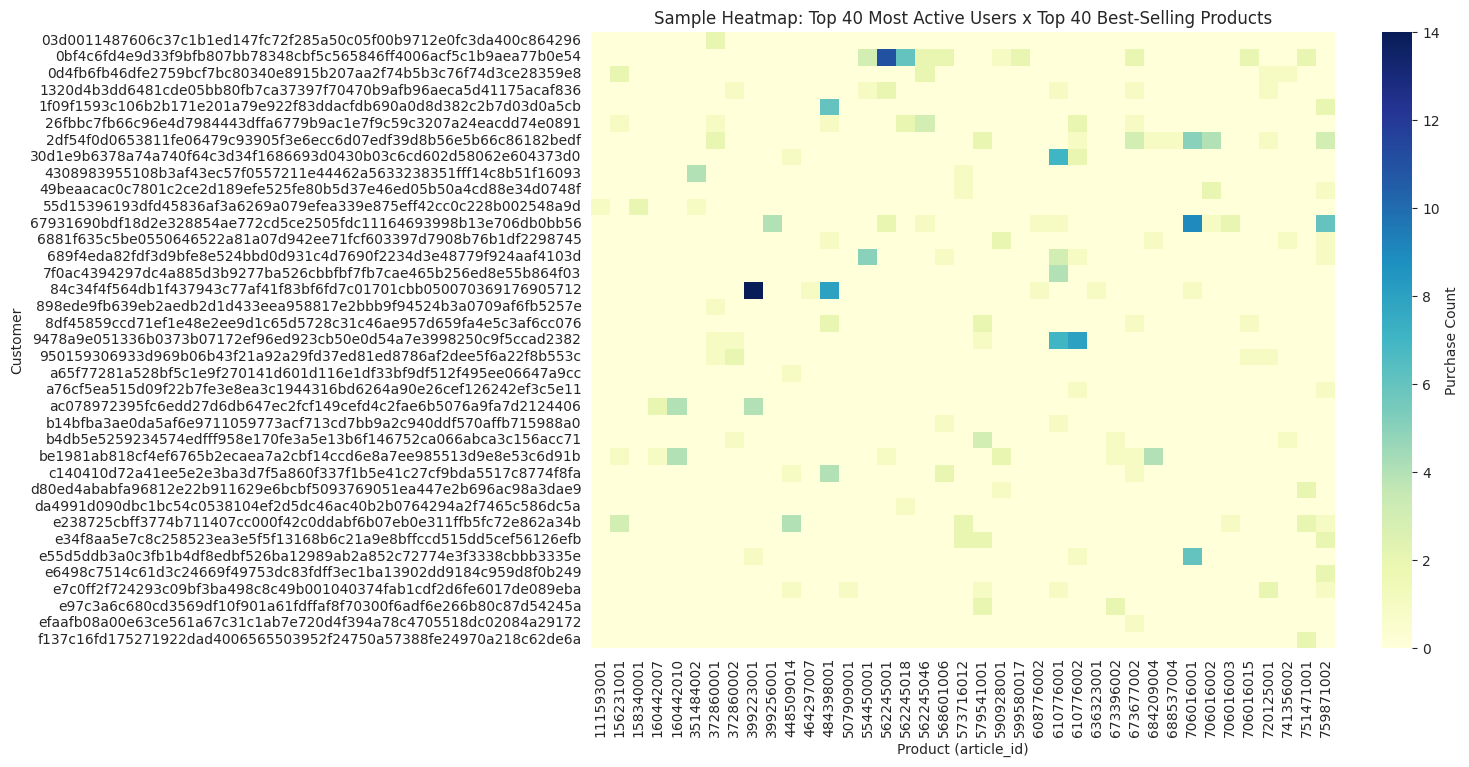

In [ ]:
top_users = user_activity.sort_values("num_interactions", ascending=False).head(40)["customer_id"]
top_products = product_popularity.sort_values("num_purchases", ascending=False).head(40)["article_id"]

sample = transactions[
    transactions["customer_id"].isin(top_users) & transactions["article_id"].isin(top_products)
]
sample_matrix = sample.pivot_table(
    index="customer_id", columns="article_id", aggfunc="size", fill_value=0
)

plt.figure(figsize=(12, 8))
sns.heatmap(sample_matrix, cmap="YlGnBu", cbar_kws={"label": "Purchase Count"})
plt.title("Sample Heatmap: Top 40 Most Active Users x Top 40 Best-Selling Products")
plt.xlabel("Product (article_id)")
plt.ylabel("Customer")
plt.show()


> **Why sparsity happens:** No single customer can realistically browse or buy even a tiny
> fraction of 105,000 products — true of every real e-commerce platform, not just H&M.
> **Why it's a challenge:** Collaborative filtering (especially user-user CF and matrix
> factorization) relies on finding overlapping patterns between users; when the matrix is
> 99.999%+ empty, there is very little overlap to learn from, especially for low-activity users
> — this is why a hybrid approach (falling back to content-based similarity when collaborative
> signal is too thin) is the right strategy, not an optional nice-to-have.


### Part F: Content-Based Filtering Feasibility

**F.1 Inspect available text/categorical fields**

In [ ]:
content_fields = ["prod_name", "product_type_name", "product_group_name",
                   "graphical_appearance_name", "colour_group_name",
                   "department_name", "index_name", "section_name",
                   "garment_group_name", "detail_desc"]

print("Missing value check on content-relevant fields:")
display(articles[content_fields].isnull().sum().to_frame("missing_count"))

print("\nSample of content fields:")
display(articles[content_fields].head(5))

print("\nAverage description length (words):")
desc_lengths = articles["detail_desc"].dropna().apply(lambda x: len(str(x).split()))
print(desc_lengths.describe())


Missing value check on content-relevant fields:


,missing_count
prod_name,0
product_type_name,0
product_group_name,0
graphical_appearance_name,0
colour_group_name,0
department_name,0
index_name,0
section_name,0
garment_group_name,0
detail_desc,416



Sample of content fields:


,prod_name,product_type_name,product_group_name,graphical_appearance_name,colour_group_name,department_name,index_name,section_name,garment_group_name,detail_desc
0,Strap top,Vest top,Garment Upper body,Solid,Black,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
1,Strap top,Vest top,Garment Upper body,Solid,White,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
2,Strap top (1),Vest top,Garment Upper body,Stripe,Off White,Jersey Basic,Ladieswear,Womens Everyday Basics,Jersey Basic,Jersey top with narrow shoulder straps.
3,OP T-shirt (Idro),Bra,Underwear,Solid,Black,Clean Lingerie,Lingeries/Tights,Womens Lingerie,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,OP T-shirt (Idro),Bra,Underwear,Solid,White,Clean Lingerie,Lingeries/Tights,Womens Lingerie,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."



Average description length (words):
count    105126.000000
mean         23.902194
std          11.623311
min           2.000000
25%          16.000000
50%          22.000000
75%          30.000000
max         121.000000
Name: detail_desc, dtype: float64


**F.2 Category cardinality**

In [ ]:
for col in ["product_type_name", "product_group_name", "department_name",
            "index_name", "section_name", "garment_group_name", "colour_group_name"]:
    print(f"{col}: {articles[col].nunique()} unique values")


product_type_name: 131 unique values
product_group_name: 19 unique values
department_name: 250 unique values
index_name: 10 unique values
section_name: 56 unique values
garment_group_name: 21 unique values
colour_group_name: 50 unique values


> **Which features we'll use:**
> - `detail_desc` — free-text description → ideal for **TF-IDF** or embeddings, the richest content signal
> - `prod_name`, `product_type_name`, `product_group_name`, `department_name`, `garment_group_name`,
>   `colour_group_name` — categorical fields → one-hot encode or concatenate into a combined
>   "content string" before TF-IDF
>
> **Text preprocessing needed:** lowercasing, removing punctuation/stopwords, and handling missing
> `detail_desc` rows — not done yet, just noted for the next step.
>
> **TF-IDF feasibility:** Yes — `detail_desc` has real natural-language content (not hashed, not
> just codes), so TF-IDF is directly applicable.


### Part G: Collaborative Filtering Feasibility

**G.1 Feasibility summary based on measured stats**

In [ ]:
print("COLLABORATIVE FILTERING FEASIBILITY CHECK")
print("="*50)
print(f"Number of users: {num_users:,}")
print(f"Number of products: {num_items:,}")
print(f"Number of interactions: {num_interactions:,}")
print(f"Sparsity: {sparsity*100:.6f}%")
print(f"Average interactions per user: {user_activity['num_interactions'].mean():.2f}")
print(f"Median interactions per user: {user_activity['num_interactions'].median():.2f}")


COLLABORATIVE FILTERING FEASIBILITY CHECK
Number of users: 1,362,281
Number of products: 104,547
Number of interactions: 27,306,439
Sparsity: 99.980827%
Average interactions per user: 23.33
Median interactions per user: 9.00


> **Assessment:**
> - **User-user CF:** Feasible in principle (large user base), but at 99.999%+ sparsity, raw
>   overlap-based similarity will be noisy for most users — needs restriction to active users or
>   dimensionality reduction first.
> - **Item-item CF:** More promising here — with ~105K items vs ~1.37M users, the item-item
>   similarity space is smaller and popular items have enough co-purchase signal.
> - **Matrix factorization (SVD / ALS):** Well-suited to this scale/sparsity — exactly the kind
>   of large, sparse, implicit-feedback data ALS-style factorization (used in production systems
>   like Spotify/Amazon) is designed for, versus naive dense SVD which is computationally infeasible here.


### Part H: Visualizations Recap
All required plots (purchase/rating distribution, user activity histogram, product popularity
distribution, category distribution, top products, long-tail plot, sample heatmap) were generated
in the cells above (Parts B, C, D, E) — no separate cells needed.


### Part I: Business Insights Summary

**I.1 Consolidated EDA summary printout**

In [ ]:
print("="*60)
print("EDA SUMMARY REPORT")
print("="*60)

print(f"""
1. KEY OBSERVATIONS
   - {num_users:,} users, {num_items:,} products, {num_interactions:,} unique interactions
   - Matrix sparsity: {sparsity*100:.4f}% (extremely sparse, as expected for e-commerce)
   - User activity and product popularity both follow long-tail distributions
   - No explicit ratings exist; purchases are implicit binary-dominant signals

2. DATASET STRENGTHS
   - Large scale, real transactional data (not synthetic)
   - Rich product metadata (name, category, description) supports content-based filtering
   - Sufficient interaction volume supports collaborative filtering / matrix factorization

3. DATASET WEAKNESSES
   - No explicit ratings — must rely on implicit signals
   - Extreme sparsity — most users have very few purchases
   - Cold-start users/items exist (present in customers/articles but absent from transactions)

4. EXPECTED MODELING CHALLENGES
   - Cold-start for new/low-activity users and unpopular products
   - Popularity bias risk if not corrected
   - Scale: dense computations are infeasible; sparse/approximate methods required

5. RECOMMENDED STRATEGY
   - Content-based filtering for cold-start and low-activity users (using detail_desc + categorical fields)
   - Item-item CF or ALS-based matrix factorization for users with sufficient history
   - Hybrid: blend or switch between the two based on user activity level
""")


EDA SUMMARY REPORT

1. KEY OBSERVATIONS
   - 1,362,281 users, 104,547 products, 27,306,439 unique interactions
   - Matrix sparsity: 99.9808% (extremely sparse, as expected for e-commerce)
   - User activity and product popularity both follow long-tail distributions
   - No explicit ratings exist; purchases are implicit binary-dominant signals

2. DATASET STRENGTHS
   - Large scale, real transactional data (not synthetic)
   - Rich product metadata (name, category, description) supports content-based filtering
   - Sufficient interaction volume supports collaborative filtering / matrix factorization

3. DATASET WEAKNESSES
   - No explicit ratings — must rely on implicit signals
   - Extreme sparsity — most users have very few purchases
   - Cold-start users/items exist (present in customers/articles but absent from transactions)

4. EXPECTED MODELING CHALLENGES
   - Cold-start for new/low-activity users and unpopular products
   - Popularity bias risk if not corrected
   - Scale: dense

---
## Deliverable: EDA Suitability Verdict

| Approach | Verdict | Basis |
|---|---|---|
| **Content-based filtering** | Suitable | Rich `detail_desc` text + multiple categorical fields, low missing-value rate |
| **Collaborative filtering** | Suitable (with care) | Large interaction volume, but extreme sparsity means item-item CF / ALS matrix factorization will work better than naive user-user CF |
| **Hybrid system** | Strongly suitable | Complementary strengths — content-based covers cold-start gaps that CF alone can't |

**Recommended next preprocessing step (not started here):** cleaning `detail_desc` missing
values, building the combined content-text field, encoding categorical article/customer
features, and deciding on an activity-based cutoff (e.g., minimum purchase count) to filter
users/items for the collaborative filtering pipeline — to be tackled in Step 3.

**Scope reminder:** this notebook stops at EDA. No preprocessing, modeling, or deployment code
is included.
